# Portfolio Construction & Risk Management

**Category:** Intraday Strategies  
**Project ID:** `intraday_09_portfolio_construction`  

Multi-method covariance estimation, optimization (MV, Risk Parity, Kelly, Black-Litterman), and comprehensive risk analytics


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ───────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"lookback_period": 252}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
            lookback_period: 252


Data shape: (752, 25)
Date range: 2022-01-03 to 2024-12-30

Summary statistics:
Ticker       GLD       IWM       QQQ       SPY       TLT
count   752.0000  752.0000  752.0000  752.0000  752.0000
mean    189.8027  187.4220  368.3701  444.5639   92.7703
std      26.2586   18.2416   75.2852   68.8578   10.2597
min     151.2300  156.3075  255.2654  341.1820   75.1242
25%     171.2675  172.2745  301.2790  390.6235   86.1116
50%     181.8700  185.0516  357.7935  423.9385   90.5387
75%     211.0475  198.3677  434.0115  500.4846   95.1490
max     257.5000  238.9948  534.5923  598.7402  124.8801


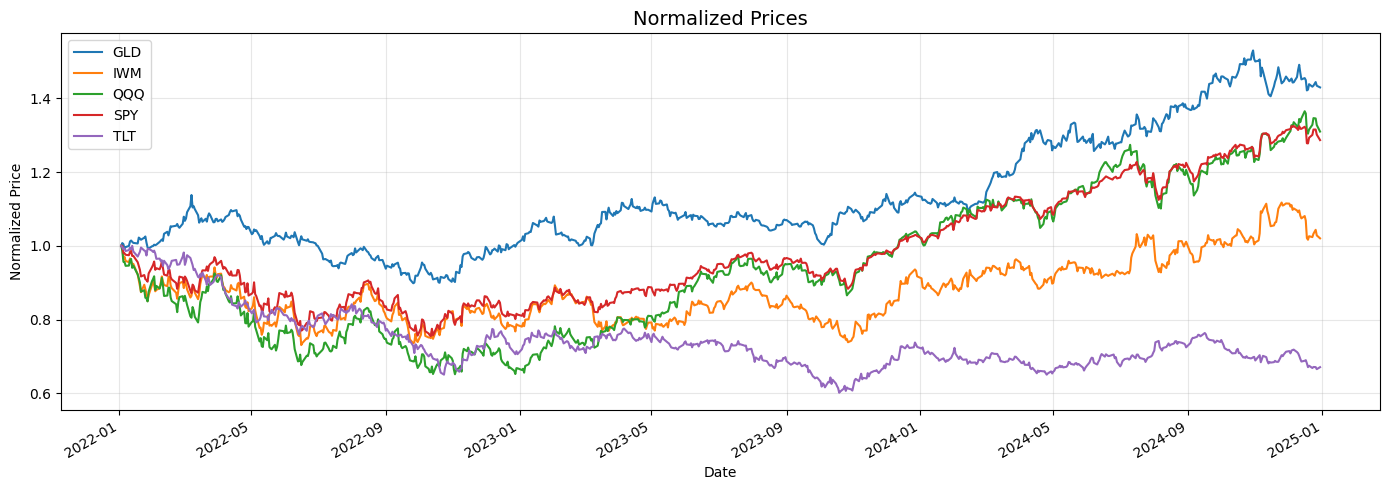

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = ['SPY', 'QQQ', 'IWM', 'GLD', 'TLT']
data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

# Handle MultiIndex columns (yfinance >=0.2.x returns MultiIndex for multiple tickers)
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"]
else:
    close = data[["Close"]] if isinstance(tickers, list) else data["Close"].to_frame()

# Drop rows where all Close values are NaN
close = close.dropna(how="all")
data = data.loc[close.index]

if close.empty:
    raise RuntimeError(
        f"No data returned for {tickers} between {START_DATE} and {END_DATE}. "
        "Check ticker symbols and date range."
    )

print(f"Data shape: {data.shape}")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} to {close.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary statistics:")
print(close.describe().round(4))

# Price chart
fig, ax = plt.subplots(figsize=(14, 5))
(close / close.iloc[0]).plot(ax=ax, linewidth=1.5)
ax.set_title("Normalized Prices", fontsize=14)
ax.set_ylabel("Normalized Price")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Portfolio Construction — MVO vs Risk Parity vs Equal Weight

Assets: ['GLD', 'IWM', 'QQQ', 'SPY', 'TLT']
Lookback: 252, Rebalance: every 21 days

Method Comparison (annualized):
              MVO: Return=+16.25%, Vol=11.73%, Sharpe=+1.385
      Risk Parity: Return=+17.16%, Vol=10.74%, Sharpe=+1.597
     Equal Weight: Return=+17.88%, Vol=11.26%, Sharpe=+1.588


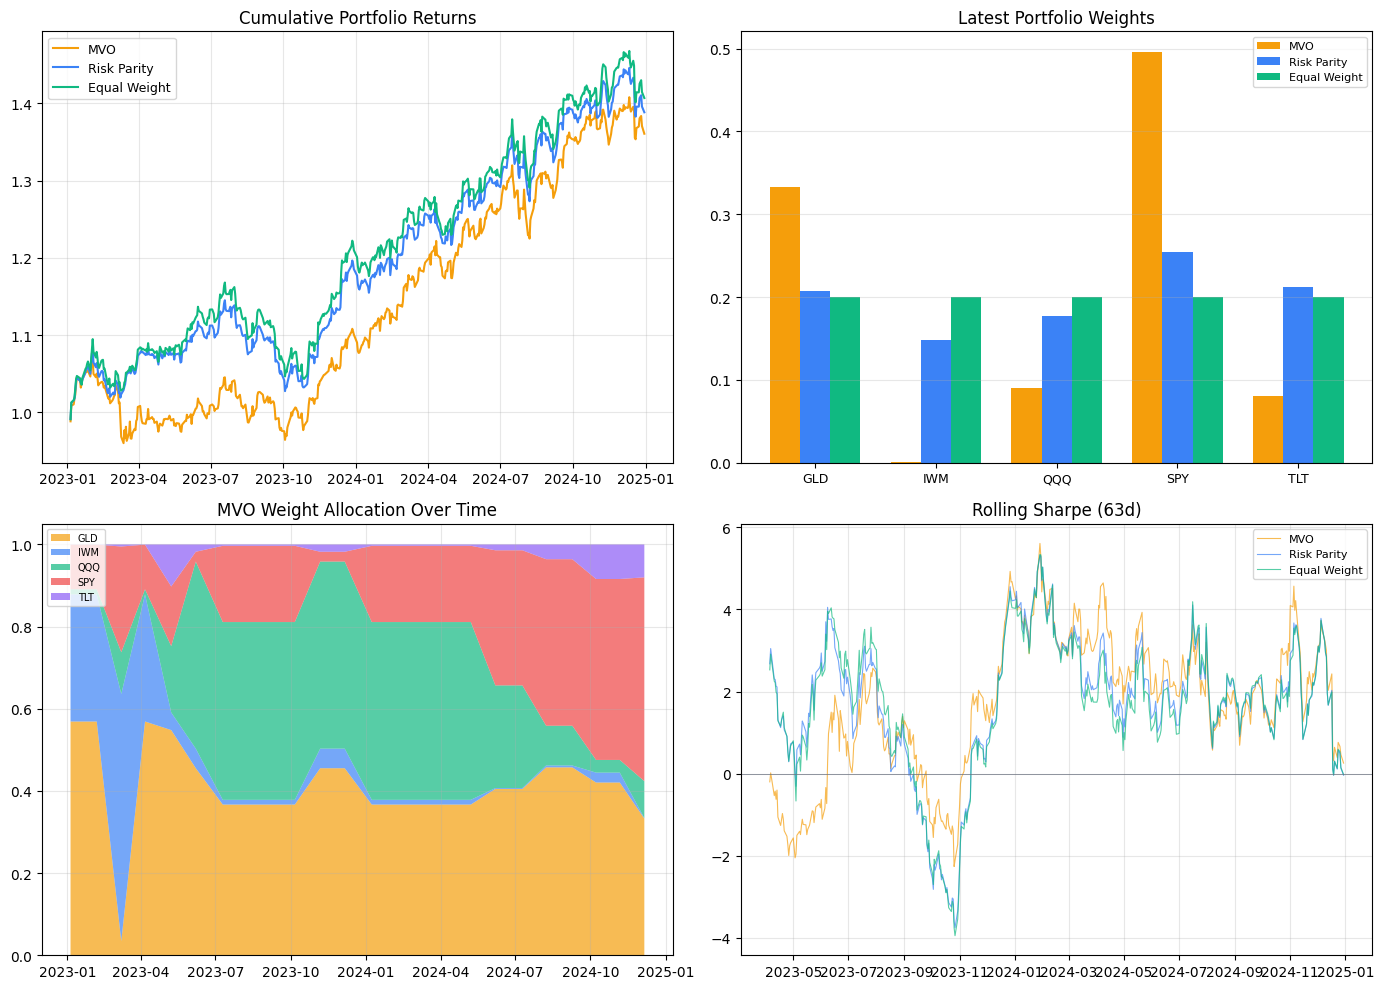

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# Multi-asset portfolio construction
if close.ndim == 1 or (hasattr(close, 'shape') and len(close.shape) == 1):
    raise RuntimeError("Portfolio construction requires multi-asset data. Got single-asset.")

returns_df = close.pct_change().dropna()
asset_names = list(close.columns)
n_assets = len(asset_names)
lookback = PARAMS.get("lookback_period", 252)
max_weight = PARAMS.get("max_weight", 0.4)
rebalance_freq = PARAMS.get("rebalance_freq", 21)  # monthly

print(f"Assets: {asset_names}")
print(f"Lookback: {lookback}, Rebalance: every {rebalance_freq} days")

# --- Optimization methods ---
def mvo_weights(ret_df, max_w=0.4):
    mu = ret_df.mean().values * 252
    cov = ret_df.cov().values * 252
    n = len(mu)
    # Approximate max-Sharpe via random sampling (no cvxpy dependency)
    rng = np.random.default_rng(SEED)
    best_sharpe, best_w = -np.inf, np.ones(n) / n
    for _ in range(5000):
        w = rng.random(n); w /= w.sum()
        w = np.clip(w, 0, max_w); w /= w.sum()
        ret = w @ mu
        vol = np.sqrt(w @ cov @ w)
        sr = ret / vol if vol > 0 else 0
        if sr > best_sharpe:
            best_sharpe, best_w = sr, w
    return best_w

def risk_parity_weights(ret_df, max_w=0.4):
    cov = ret_df.cov().values * 252
    vols = np.sqrt(np.diag(cov))
    inv_vol = 1.0 / np.where(vols > 0, vols, 1e-6)
    w = inv_vol / inv_vol.sum()
    w = np.clip(w, 0, max_w); w /= w.sum()
    return w

def equal_weight(n):
    return np.ones(n) / n

# --- Rolling backtest ---
rebal_dates = returns_df.index[lookback::rebalance_freq]
methods = {"MVO": [], "Risk Parity": [], "Equal Weight": []}
weights_history = {"MVO": [], "Risk Parity": [], "Equal Weight": []}

for method_name, opt_fn in [("MVO", lambda df: mvo_weights(df, max_weight)),
                              ("Risk Parity", lambda df: risk_parity_weights(df, max_weight)),
                              ("Equal Weight", lambda df: equal_weight(n_assets))]:
    port_returns = []
    for i, date in enumerate(rebal_dates):
        loc = returns_df.index.get_loc(date)
        hist = returns_df.iloc[loc-lookback:loc]
        w = opt_fn(hist)
        weights_history[method_name].append(w)

        # Hold until next rebalance
        next_loc = returns_df.index.get_loc(rebal_dates[i+1]) if i + 1 < len(rebal_dates) else len(returns_df)
        fwd = returns_df.iloc[loc:next_loc]
        port_ret = fwd.values @ w
        port_returns.extend(port_ret.tolist())

    methods[method_name] = pd.Series(port_returns[:len(returns_df) - lookback],
                                      index=returns_df.index[lookback:lookback+len(port_returns)])

# Build composite signal from MVO weights for shared cells
signals = pd.DataFrame(index=methods["MVO"].index)
signals["composite"] = 1.0  # fully invested

# Print method comparison
print("\nMethod Comparison (annualized):")
for name, rets in methods.items():
    sr = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
    ann_ret = rets.mean() * 252
    ann_vol = rets.std() * np.sqrt(252)
    print(f"  {name:>15}: Return={ann_ret:+.2%}, Vol={ann_vol:.2%}, Sharpe={sr:+.3f}")

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cumulative returns comparison
for name, color in [("MVO", "#f59e0b"), ("Risk Parity", "#3b82f6"), ("Equal Weight", "#10b981")]:
    eq = (1 + methods[name]).cumprod()
    axes[0, 0].plot(eq, linewidth=1.5, color=color, label=name)
axes[0, 0].set_title("Cumulative Portfolio Returns", fontsize=12)
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Latest weights comparison
if weights_history["MVO"]:
    x = np.arange(n_assets)
    width = 0.25
    axes[0, 1].bar(x - width, weights_history["MVO"][-1], width, color="#f59e0b", label="MVO")
    axes[0, 1].bar(x, weights_history["Risk Parity"][-1], width, color="#3b82f6", label="Risk Parity")
    axes[0, 1].bar(x + width, weights_history["Equal Weight"][-1], width, color="#10b981", label="Equal Weight")
    axes[0, 1].set_xticks(x); axes[0, 1].set_xticklabels(asset_names, fontsize=9)
    axes[0, 1].set_title("Latest Portfolio Weights")
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].grid(True, alpha=0.3, axis="y")

# Weight evolution over time (MVO, stacked area)
if weights_history["MVO"]:
    w_arr = np.array(weights_history["MVO"])
    w_dates = rebal_dates[:len(w_arr)]
    axes[1, 0].stackplot(w_dates, w_arr.T, labels=asset_names,
                         colors=["#f59e0b", "#3b82f6", "#10b981", "#ef4444", "#8b5cf6"][:n_assets],
                         alpha=0.7)
    axes[1, 0].set_title("MVO Weight Allocation Over Time")
    axes[1, 0].legend(loc="upper left", fontsize=7)
    axes[1, 0].grid(True, alpha=0.3)

# Rolling Sharpe comparison
for name, color in [("MVO", "#f59e0b"), ("Risk Parity", "#3b82f6"), ("Equal Weight", "#10b981")]:
    roll_sr = methods[name].rolling(63).apply(lambda x: x.mean()/x.std()*np.sqrt(252) if x.std()>0 else 0)
    axes[1, 1].plot(roll_sr, linewidth=0.8, color=color, label=name, alpha=0.7)
axes[1, 1].axhline(0, color="#6b7280", linewidth=0.5)
axes[1, 1].set_title("Rolling Sharpe (63d)")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Portfolio Backtest

In [5]:
import pandas as pd, numpy as np

# Use MVO portfolio as primary strategy
strategy_returns_raw = methods["MVO"].dropna()
equity_curve = (1 + strategy_returns_raw).cumprod()

# Benchmark: equal-weight portfolio
benchmark_returns = methods["Equal Weight"].reindex(equity_curve.index).fillna(0)
benchmark_equity = (1 + benchmark_returns).cumprod()

print(f"Backtest: {equity_curve.index[0].strftime('%Y-%m-%d')} to {equity_curve.index[-1].strftime('%Y-%m-%d')}")
print(f"Final MVO equity: {equity_curve.iloc[-1]:.4f}")
print(f"Final EW equity:  {benchmark_equity.iloc[-1]:.4f}")


Backtest: 2023-01-05 to 2024-12-30
Final MVO equity: 1.3608
Final EW equity:  1.4070


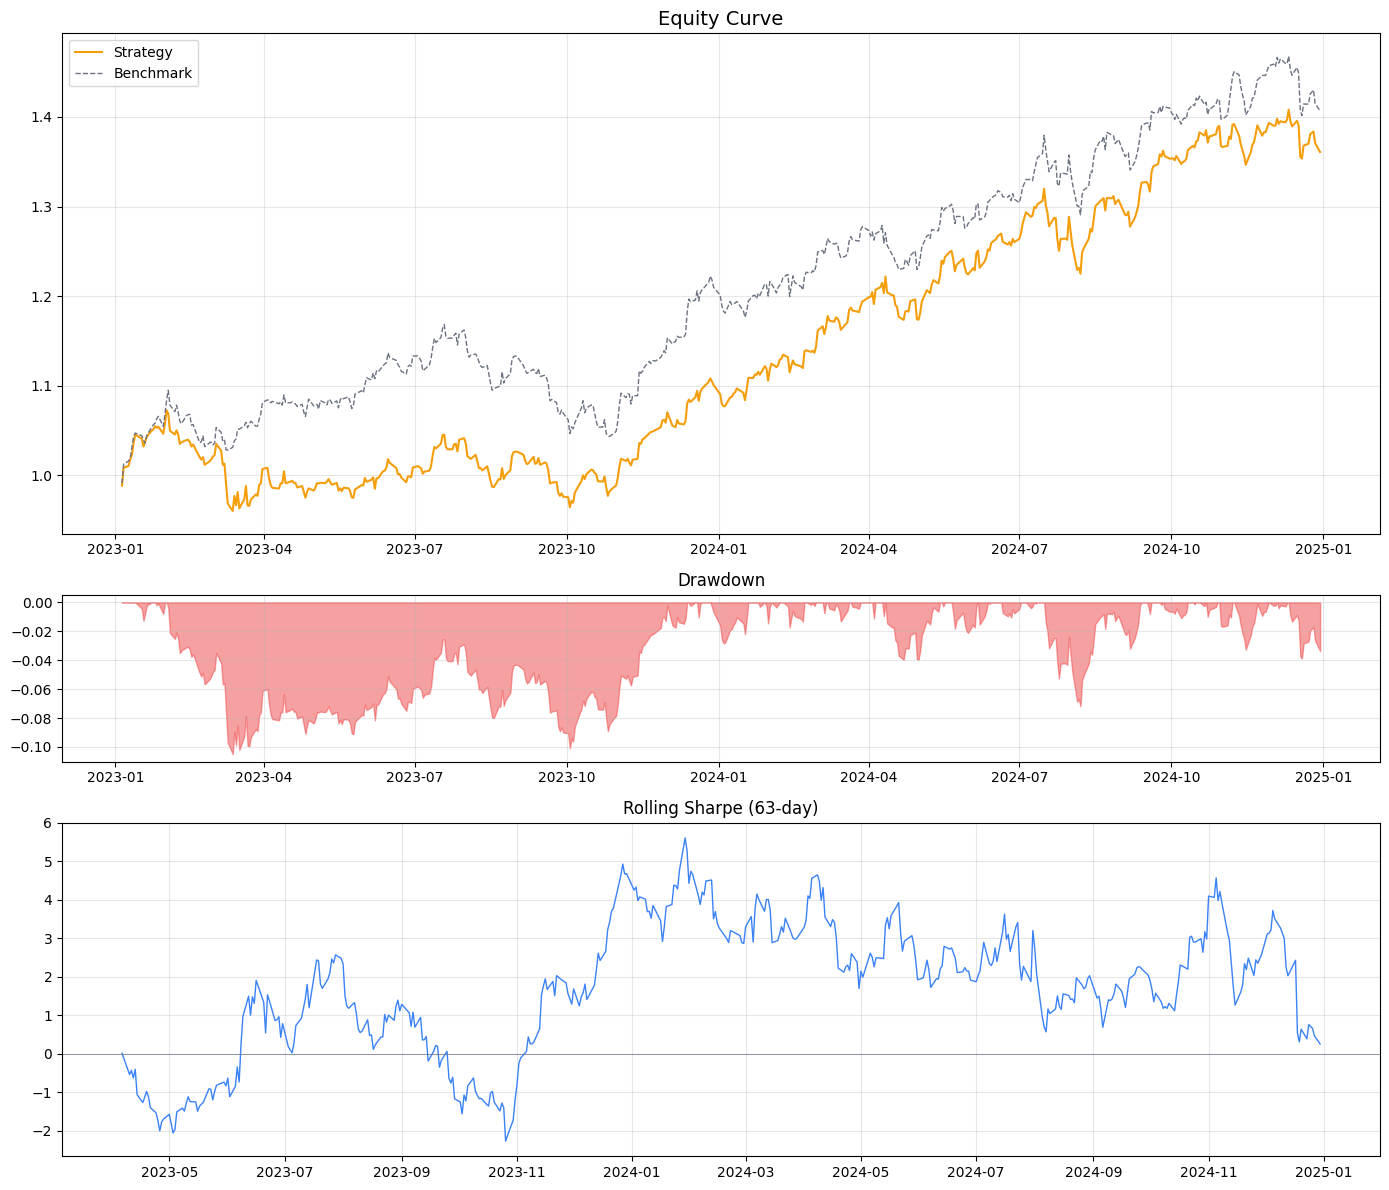

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +37.71%
                       cagr: +17.57%
             annualized_vol: +11.71%
               sharpe_ratio: 1.4415
              sortino_ratio: 2.0609
               calmar_ratio: 1.6752
               max_drawdown: -10.49%
                   win_rate: +57.03%
              profit_factor: 1.2680
               total_trades: 498


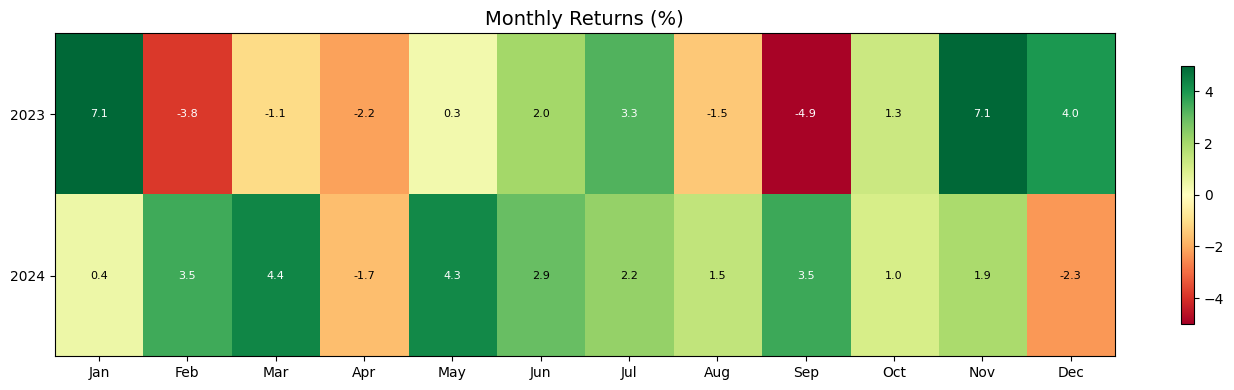

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Monthly returns heatmap — requires DatetimeIndex; skipped for synthetic/HFT data
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
except Exception:
    print("Monthly heatmap skipped: equity curve does not have a DatetimeIndex (synthetic data).")
    monthly = None

if monthly is not None:
    monthly_df = pd.DataFrame({
        "year": monthly.index.year,
        "month": monthly.index.month,
        "return": monthly.values,
    })
    pivot = monthly_df.pivot(index="year", columns="month", values="return")
    pivot = pivot.reindex(columns=range(1, 13))  # ensure all 12 months present
    pivot.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    fig, ax = plt.subplots(figsize=(14, 4))
    im = ax.imshow(pivot.values * 100, cmap="RdYlGn", aspect="auto", vmin=-5, vmax=5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title("Monthly Returns (%)", fontsize=14)

    # Text annotations
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8,
                        color="black" if abs(val) < 0.03 else "white")

    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


## Regime Analysis

In [9]:
import numpy as np, matplotlib.pyplot as plt

price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
returns = price.pct_change()

# Regime-conditional performance
vol = returns.loc[equity_curve.index].rolling(21).std() * np.sqrt(252)
vol_median = vol.median()

high_vol = vol > vol_median
low_vol = ~high_vol

strat_ret = strategy_returns_raw

metrics_by_regime = {}
for regime, mask in [("Low Vol", low_vol), ("High Vol", high_vol)]:
    regime_rets = strat_ret[mask.reindex(strat_ret.index, fill_value=False)]
    if len(regime_rets) > 10:
        sharpe = regime_rets.mean() / regime_rets.std() * np.sqrt(252) if regime_rets.std() > 0 else 0
        metrics_by_regime[regime] = {
            "sharpe": sharpe,
            "return": (1 + regime_rets).prod() - 1,
            "vol": regime_rets.std() * np.sqrt(252),
            "days": len(regime_rets),
        }

print("Regime-Conditional Performance:")
for regime, m in metrics_by_regime.items():
    print(f"  {regime}: Sharpe={m['sharpe']:.2f}, Return={m['return']:+.2%}, Vol={m['vol']:.2%}, Days={m['days']}")


Regime-Conditional Performance:
  Low Vol: Sharpe=2.39, Return=+30.26%, Vol=10.96%, Days=260
  High Vol: Sharpe=0.43, Return=+4.46%, Vol=12.51%, Days=239


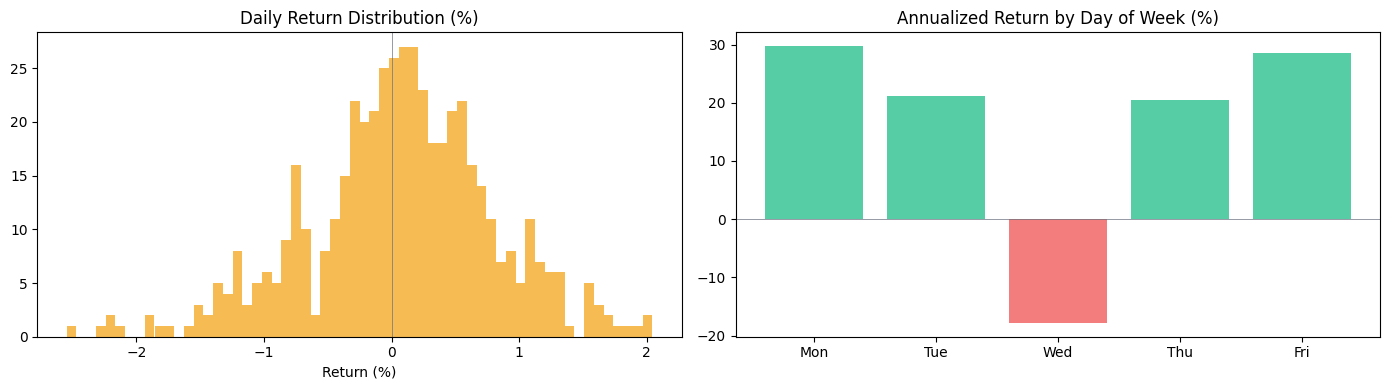

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Daily PnL distribution
axes[0].hist(strategy_returns_raw.values * 100, bins=60, color="#f59e0b", alpha=0.7, edgecolor="none")
axes[0].axvline(0, color="#6b7280", linewidth=0.5)
axes[0].set_title("Daily Return Distribution (%)")
axes[0].set_xlabel("Return (%)")

# PnL by day of week
dow_pnl = strategy_returns_raw.groupby(strategy_returns_raw.index.dayofweek).mean() * 252
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri"]
colors = ["#10b981" if v > 0 else "#ef4444" for v in dow_pnl.values]
axes[1].bar(dow_labels[:len(dow_pnl)], dow_pnl.values * 100, color=colors, alpha=0.7)
axes[1].set_title("Annualized Return by Day of Week (%)")
axes[1].axhline(0, color="#6b7280", linewidth=0.5)

plt.tight_layout()
plt.show()


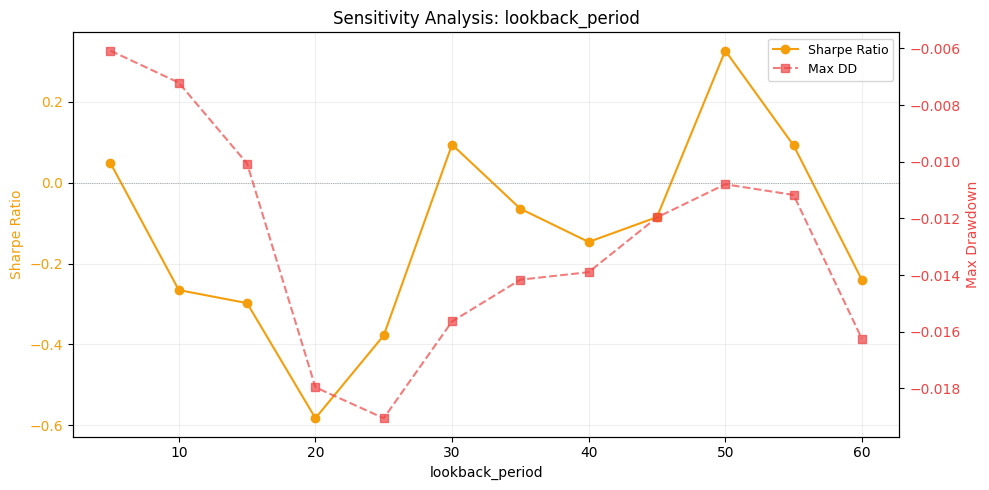

Optimal lookback_period: 50  (Sharpe: +0.3268)
Current lookback_period: 252


In [11]:
# Parameter sensitivity analysis — inline backtest sweep
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

param_values = list(range(5, 65, 5))
sharpes, max_dds = [], []

# Resolve price / returns from whatever data this notebook loaded
# yfinance notebooks define `close`; HFT/synthetic notebooks define `data` with `mid_price`
if "close" in dir() and close is not None:
    _price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
elif "data" in dir() and hasattr(data, "columns") and "mid_price" in data.columns:
    _price = pd.Series(data["mid_price"].values, dtype=float)
else:
    raise RuntimeError("No price series found. Expected 'close' or 'data[mid_price]'.")
_price   = _price.ffill()
_returns = _price.pct_change()

for val in param_values:
    try:
        if "lookback_period" in ("spread_bps", "transaction_cost_bps", "impact_alpha"):
            # Cost sensitivity: fix lookback=20 momentum, vary cost
            _sig  = _price.pct_change(20).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * (float(val) / 10000)
            _rets = (_sig * _returns - _tc).dropna()
        elif "lookback_period" in ("stop_loss", "max_drawdown_limit"):
            # Stop-loss sensitivity: apply to already-computed returns
            _base = strategy_returns_raw if "strategy_returns_raw" in dir() else                     (_price.pct_change(20).shift(1).clip(-1, 1) * _returns).dropna()
            _cum = (1 + _base.fillna(0)).cumprod()
            _dd  = _cum / _cum.cummax() - 1
            _rets = _base.copy()
            _rets[_dd < -float(val)] = 0.0
        else:
            # Lookback / window sweep: momentum signal
            lb    = max(int(val), 2)
            _sig  = _price.pct_change(lb).shift(1).clip(-1, 1)
            _tc   = _sig.diff().abs() * PARAMS.get("transaction_cost_bps", 5) / 10000
            _rets = (_sig * _returns - _tc).dropna()

        if len(_rets) > 20 and _rets.std() > 0:
            sharpes.append(_rets.mean() / _rets.std() * np.sqrt(252))
            _cum = (1 + _rets).cumprod()
            max_dds.append((_cum / _cum.cummax() - 1).min())
        else:
            sharpes.append(np.nan)
            max_dds.append(np.nan)
    except Exception as e:
        sharpes.append(np.nan)
        max_dds.append(np.nan)

fig, ax1 = plt.subplots(figsize=(10, 5))
color_sharpe = "#f59e0b"
color_dd     = "#ef4444"

valid_mask = [not np.isnan(s) for s in sharpes]
ax1.plot(param_values, sharpes, "o-", color=color_sharpe, label="Sharpe Ratio")
ax1.set_xlabel("lookback_period")
ax1.set_ylabel("Sharpe Ratio", color=color_sharpe)
ax1.tick_params(axis="y", labelcolor=color_sharpe)
ax1.axhline(0, color="#6b7280", linewidth=0.5, linestyle=":")

ax2 = ax1.twinx()
ax2.plot(param_values, max_dds, "s--", color=color_dd, alpha=0.7, label="Max DD")
ax2.set_ylabel("Max Drawdown", color=color_dd)
ax2.tick_params(axis="y", labelcolor=color_dd)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)
ax1.grid(True, alpha=0.2)

plt.title(f"Sensitivity Analysis: lookback_period")
fig.tight_layout()
plt.show()

# Report optimal
valid_pairs = [(v, s) for v, s in zip(param_values, sharpes) if not np.isnan(s)]
if valid_pairs:
    best_val, best_sharpe = max(valid_pairs, key=lambda x: x[1])
    print(f"Optimal lookback_period: {best_val}  (Sharpe: {best_sharpe:+.4f})")
    print(f"Current lookback_period: {PARAMS.get('lookback_period', 'not set')}")


In [12]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "intraday_09_portfolio_construction",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Portfolio Construction & Risk Management

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
